# Where the Price Isn't Published

### Estimating apartment prices in Finland's thin housing markets and what they reveal about affordability

---

## Project Summary

Statistics Finland publishes apartment prices in euros per square metre (€/m²) for Finnish postal code areas when enough housing transactions have occurred. In areas with very few transactions, the price is suppressed to protect the privacy of individual buyers and sellers.

This creates a systematic information gap. Many smaller towns, rural centres, and low-transaction housing markets have an existing apartment stock but no published price information. As a result, assessing housing affordability in these areas becomes difficult.

This project investigates whether neighbourhood-level socioeconomic, demographic, and housing characteristics can be used to estimate apartment prices for postal code areas where the official price is unavailable.

### Research Question

> **Can neighbourhood characteristics available in Statistics Finland's Paavo open data explain enough variation in apartment prices to produce useful estimates for postal code areas where prices are suppressed?**

### Target Variable

The target variable is:

**Average apartment price per square metre (€/m²) in a postal code area for a given year.**

### Hypothesis

Neighbourhood socioeconomic and built-environment characteristics are expected to explain a substantial share of the variation in apartment prices between Finnish postal code areas.

In particular, I expect:

- higher household income to be associated with higher apartment prices,
- a higher share of residents with higher education to be associated with higher prices,
- unemployment and household composition to contribute to differences between areas,
- dwelling characteristics and tenure structure to influence local prices,
- and municipality or regional location to explain a substantial part of price variation because Finnish housing markets are geographically segmented.

The relationship can be summarised as:

**Neighbourhood characteristics → Apartment price (€/m²)**

### Approach

The project uses annual postal-code-level data from **2020–2024**.

The modelling workflow is:

1. Combine apartment price data with Paavo neighbourhood characteristics by postal code and year.
2. Identify areas where apartment prices are published, suppressed, or unavailable because no transactions occurred.
3. Train and evaluate regression models using only observations with known prices.
4. Use a grouped validation strategy so that the same postal code does not appear in both training and test data.
5. Compare model performance using **RMSE, MAE, and R²**.
6. Select a final model based on predictive performance, interpretability, and suitability for the intended use.
7. Apply the selected model to areas where apartment prices are suppressed.
8. Use published or estimated prices together with household income to explore housing affordability.

### Housing Affordability Application

For each postal code area, a simplified affordability indicator will be calculated as:

**Estimated cost of a 50 m² apartment ÷ average household disposable income**

This price-to-income measure can be combined with indicators such as recent dwelling-stock growth to identify areas where housing costs appear high relative to local incomes and where housing supply has not expanded correspondingly.

The resulting estimates are intended for **screening, comparison, and policy-oriented analysis**, not for individual property valuation.

### Stakeholders

Potential users of the results include:

| Stakeholder | Potential use |
|---|---|
| Municipal housing planners | Identify areas where affordability pressure may justify housing or zoning interventions |
| Regional development organisations | Compare affordability and housing-supply conditions between areas |
| Statistics Finland and open-data users | Understand where suppressed housing-price statistics create information gaps |
| Researchers and residents | Obtain approximate area-level housing-market context where published prices are unavailable |

### Success Criteria

The objective is not simply to maximise R².

A successful model should:

- achieve reasonable predictive accuracy on unseen postal code areas,
- distinguish meaningfully between areas with different housing-price levels,
- remain interpretable where possible,
- perform consistently under grouped validation,
- and clearly communicate where predictions are uncertain or potentially biased.

Model performance will primarily be evaluated using:

- **RMSE** — Root Mean Squared Error
- **MAE** — Mean Absolute Error
- **R²** — Coefficient of Determination

### Important Limitation

Missing prices are **not random**.

Postal code areas with suppressed prices tend to have fewer housing transactions than the areas used to train the model. Therefore, even a carefully designed held-out test score may be somewhat optimistic when compared with the model's true performance on suppressed-price areas.

Predicted values will therefore be presented explicitly as **model estimates rather than official Statistics Finland statistics**.

### Data Sources

The project uses open aggregated data from **Statistics Finland**:

- **Paavo postal code area statistics** — socioeconomic, demographic, household, dwelling, employment, and education characteristics.
- **Prices of dwellings by postal code area** — apartment prices per square metre and transaction counts.

The analysis covers **2020–2024**.

No individual-level or personally identifying information is used. All data is pre-aggregated by Statistics Finland.

---

## Notebook Structure

1. **Title and Summary**
2. **Imports and Configuration**
3. **Data Loading and Preparation**
4. **Exploration and Visualisation**
5. **Modelling**
6. **Evaluation and Diagnostics**
7. **Conclusions, Stakeholder Summary, and Limitations**

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GroupShuffleSplit

# Load files

## Load target files

In [2]:
# Load 1 dataset for check its structure
df_t_test = pd.read_csv("../data/raw/price_per_square_meter_2020.csv")
df_t_test.head()

,,,,,,"13mu -- Prices per square meter of old dwellings in housing companies and numbers of transactions by postal code area, yearly, 2009-2025"
Postal code,"Price per square meter (EUR/m2) 2020 Blocks of flats, one-room flat","Price per square meter (EUR/m2) 2020 Blocks of flats, two-room flat","Price per square meter (EUR/m2) 2020 Blocks of flats, three-room flat+","Number of sales, asset transfer tax data starting from 2020 2020 Blocks of flats, one-room flat","Number of sales, asset transfer tax data starting from 2020 2020 Blocks of flats, two-room flat","Number of sales, asset transfer tax data start..."
00100 Helsinki keskusta - Etu-Töölö (Helsinki),8419,7773,7153,110,178,195
00120 Punavuori - Bulevardi (Helsinki),8702,7993,8065,55,82,75
00130 Kaartinkaupunki (Helsinki),...,8588,8083,5,11,19
00140 Kaivopuisto - Ullanlinna (Helsinki),8948,8416,8811,73,69,92


In [3]:
def load_year(path, year):
    df = pd.read_csv(path, skiprows=2, encoding="utf-8-sig")

    df.columns = [
        "postal_raw",
        "price_1", "price_2", "price_3",
        "sales_1", "sales_2", "sales_3"
    ]

    rows = []

    for rooms in [1, 2, 3]:
        temp = df[["postal_raw", f"price_{rooms}", f"sales_{rooms}"]].copy()
        temp.columns = ["postal_raw", "price_per_sqm", "n_sales"]
        temp["rooms"] = rooms
        rows.append(temp)

    out = pd.concat(rows, ignore_index=True)
    out["year"] = year

    return out

In [4]:
years = [2020, 2021, 2022, 2023, 2024]

df = pd.concat(
    [load_year(f"../data/raw/price_per_square_meter_{y}.csv", y) for y in years],
    ignore_index=True,
)

In [5]:
df["postal_code"]  = df["postal_raw"].str[:5]
df["municipality"] = df["postal_raw"].str.extract(r"\((.*?)\)$")

df["price_per_sqm"] = pd.to_numeric(df["price_per_sqm"], errors="coerce")
df["n_sales"]       = pd.to_numeric(df["n_sales"], errors="coerce")

df = df[["postal_code", "municipality", "year", "rooms", "price_per_sqm", "n_sales"]]

In [6]:
display(df.shape)
df.head()

(25860, 6)

,postal_code,municipality,year,rooms,price_per_sqm,n_sales
0,00100,Helsinki,2020,1,8419.0,110.0
1,00120,Helsinki,2020,1,8702.0,55.0
2,00130,Helsinki,2020,1,NaN,5.0
3,00140,Helsinki,2020,1,8948.0,73.0
4,00150,Helsinki,2020,1,8739.0,134.0


## Load features files

In [7]:
# Load 1 dataset to check its structure
df_f_test = pd.read_csv('../data/raw/average_floor_area_per_dwelling_2020_2024.csv')
df_f_test.head()

,,,,,"12f4 -- 6. Buildings and dwellings, 2010-2024"
Postal code area,2020 Average floor area per dwelling (RA),2021 Average floor area per dwelling (RA),2022 Average floor area per dwelling (RA),2023 Average floor area per dwelling (RA),2024 Average floor area per dwelling (RA)
00100 Helsinki keskusta - Etu-Töölö (Helsinki),65.8,65.8,65.7,65.6,65.7
00120 Punavuori - Bulevardi (Helsinki),69.5,69.6,69.8,70.0,70.0
00130 Kaartinkaupunki (Helsinki),78.5,78.4,79.3,80.2,81.0
00140 Kaivopuisto - Ullanlinna (Helsinki),74.1,74.1,74.4,74.2,74.4


In [8]:
paavo_files = {
    "population":        "../data/raw/population_structure_2020_2024.csv",
    "age18plus":         "../data/raw/age_18_or_over_2020_2024.csv",
    "higher_degree":     "../data/raw/academic_degree_higher_university_level_degree_2020_2024.csv",
    "income":            "../data/raw/average_income_of_households_2020_2024.csv",
    "hh_size":           "../data/raw/average_size_of_households_2020_2024.csv",
    "hh_total":          "../data/raw/households_total_2020_2024.csv",
    "hh_rented":         "../data/raw/households_living_in_rented_dwellings_2020_2024.csv",
    "hh_one_person":     "../data/raw/one_person_households_2020_2024.csv",
    "dwellings":         "../data/raw/dwellings_2020_2024.csv",
    "dwellings_flats":   "../data/raw/dwellings_in_blocks_of_flats_2020_2024.csv",
    "avg_floor_area":    "../data/raw/average_floor_area_per_dwelling_2020_2024.csv",
    "unemployed":        "../data/raw/unemployment_new_2020_2024.csv",
    "workplaces":        "../data/raw/workplaces_total_2020_2024.csv",
}

In [9]:
def load_paavo(path, name):
    df = pd.read_csv(path, skiprows=2, encoding="utf-8-sig")

    df = df.rename(columns={df.columns[0]: "postal_raw"})
    df = df.melt(id_vars="postal_raw", var_name="year", value_name=name)

    df["year"] = df["year"].str.extract(r"(20\d{2})").astype(int)
    df["postal_code"] = df["postal_raw"].str[:5]
    df[name] = pd.to_numeric(df[name], errors="coerce")

    return df[["postal_code", "year", name]]

In [10]:
frames = [load_paavo(p, n) for n, p in paavo_files.items()]

paavo = frames[0]

for frame in frames[1:]:
    paavo = paavo.merge(
        frame,
        on=["postal_code", "year"],
        how="outer"
    )

paavo.loc[paavo["year"] == 2024, "workplaces"] = pd.NA

In [11]:
print(paavo.shape)        # expect ~15,000 rows (3018 × 5 years)
paavo.head()

(15090, 15)


,postal_code,year,population,age18plus,higher_degree,income,hh_size,hh_total,hh_rented,hh_one_person,dwellings,dwellings_flats,avg_floor_area,unemployed,workplaces
0,00100,2020,18373,16236,6023.0,70284.0,1.7,10380,5289.0,5379.0,12341.0,11721.0,65.8,1083.0,49712.0
1,00100,2021,17893,15817,5949.0,73553.0,1.7,10141,5157.0,5267.0,12321.0,11663.0,65.8,723.0,52491.0
2,00100,2022,18030,15997,5977.0,70016.0,1.7,10280,5334.0,5447.0,12337.0,11719.0,65.7,630.0,55404.0
3,00100,2023,18462,16365,6225.0,70761.0,1.7,10568,5527.0,5620.0,12440.0,11819.0,65.6,693.0,55646.0
4,00100,2024,18492,16397,6422.0,73915.0,1.7,10544,5352.0,5546.0,12469.0,11869.0,65.7,834.0,NaN


## Load geographic features

In [12]:
import geopandas as gpd

# Load postal-code geometries
gdf = gpd.read_file(
    "https://geo.stat.fi/geoserver/postialue/wfs"
    "?service=WFS&version=2.0.0&request=GetFeature"
    "&typeName=postialue:pno_2024&outputFormat=json"
)

# Rename columns into English
gdf = gdf.rename(columns={
    "posti_alue": "postal_code",
    "vuosi": "year",
    "nimi": "name_fi",
    "namn": "name_sv",
    "kunta": "municipality_code",
    "kuntanro": "municipality_number",
    "pinta_ala": "area_m2"
})

gdf.head()

,id,objectid,postal_code,year,name_fi,name_sv,municipality_code,municipality_number,area_m2,geometry
0,1,1,00100,2024,Helsinki keskusta - Etu-Töölö,Helsingfors centrum - Främre Tölö,091,91,2353278,"POLYGON ((385653.893 6671591.048, 385779.642 6..."
1,2,2,00120,2024,Punavuori - Bulevardi,Rödbergen - Bulevarden,091,91,414010,"POLYGON ((385316.092 6671076.984, 385388.492 6..."
2,3,3,00130,2024,Kaartinkaupunki,Gardesstaden,091,91,428960,"POLYGON ((386212.111 6671061.262, 386298.022 6..."
3,5,5,00150,2024,Punavuori - Eira - Hernesaari,Rödbergen - Eira - Ärtholmen,091,91,1367328,"MULTIPOLYGON (((384846.102 6669565.816, 384867..."
4,32,32,00420,2024,Kannelmäki,Gamlas,091,91,2890057,"POLYGON ((382632.09 6682138.433, 382483.046 66..."


In [13]:
# Project to EPSG:3067
# Coordinates and distances are now in metres
gdf = gdf.to_crs(epsg=3067)

# Postal-code centroid coordinates
gdf["centroid"] = gdf.geometry.centroid

gdf["centroid_x"] = gdf["centroid"].x
gdf["centroid_y"] = gdf["centroid"].y

In [14]:
gdf.head()

,id,objectid,postal_code,year,name_fi,name_sv,municipality_code,municipality_number,area_m2,geometry,centroid,centroid_x,centroid_y
0,1,1,00100,2024,Helsinki keskusta - Etu-Töölö,Helsingfors centrum - Främre Tölö,091,91,2353278,"POLYGON ((385653.893 6671591.048, 385779.642 6...",POINT (385114.002 6672390.769),385114.002032,6.672391e+06
1,2,2,00120,2024,Punavuori - Bulevardi,Rödbergen - Bulevarden,091,91,414010,"POLYGON ((385316.092 6671076.984, 385388.492 6...",POINT (385613.52 6671377.831),385613.519532,6.671378e+06
2,3,3,00130,2024,Kaartinkaupunki,Gardesstaden,091,91,428960,"POLYGON ((386212.111 6671061.262, 386298.022 6...",POINT (386227.615 6671492.049),386227.614544,6.671492e+06
3,5,5,00150,2024,Punavuori - Eira - Hernesaari,Rödbergen - Eira - Ärtholmen,091,91,1367328,"MULTIPOLYGON (((384846.102 6669565.816, 384867...",POINT (385117.961 6670308.479),385117.961363,6.670308e+06
4,32,32,00420,2024,Kannelmäki,Gamlas,091,91,2890057,"POLYGON ((382632.09 6682138.433, 382483.046 66...",POINT (382610.119 6680386.839),382610.118643,6.680387e+06


## Merge All Datasets

In [15]:
# Merge paavo dataset with geo_features
geo_features = gdf[
    [
        "postal_code",
        "municipality_code",
        "centroid_x",
        "centroid_y",
        "area_m2"
    ]
].copy()

paavo = paavo.merge(
    geo_features,
    on="postal_code",
    how="left"
)

In [16]:
paavo.head()

,postal_code,year,population,age18plus,higher_degree,income,hh_size,hh_total,hh_rented,hh_one_person,dwellings,dwellings_flats,avg_floor_area,unemployed,workplaces,municipality_code,centroid_x,centroid_y,area_m2
0,00100,2020,18373,16236,6023.0,70284.0,1.7,10380,5289.0,5379.0,12341.0,11721.0,65.8,1083.0,49712.0,091,385114.002032,6.672391e+06,2353278
1,00100,2021,17893,15817,5949.0,73553.0,1.7,10141,5157.0,5267.0,12321.0,11663.0,65.8,723.0,52491.0,091,385114.002032,6.672391e+06,2353278
2,00100,2022,18030,15997,5977.0,70016.0,1.7,10280,5334.0,5447.0,12337.0,11719.0,65.7,630.0,55404.0,091,385114.002032,6.672391e+06,2353278
3,00100,2023,18462,16365,6225.0,70761.0,1.7,10568,5527.0,5620.0,12440.0,11819.0,65.6,693.0,55646.0,091,385114.002032,6.672391e+06,2353278
4,00100,2024,18492,16397,6422.0,73915.0,1.7,10544,5352.0,5546.0,12469.0,11869.0,65.7,834.0,NaN,091,385114.002032,6.672391e+06,2353278


In [17]:
df_merged = df.merge(
  paavo,
  on=['postal_code', 'year'],
  how='left'
)

display(df_merged.shape)
df_merged.head()

(25860, 23)

,postal_code,municipality,year,rooms,price_per_sqm,n_sales,population,age18plus,higher_degree,income,...,hh_one_person,dwellings,dwellings_flats,avg_floor_area,unemployed,workplaces,municipality_code,centroid_x,centroid_y,area_m2
0,00100,Helsinki,2020,1,8419.0,110.0,18373.0,16236.0,6023.0,70284.0,...,5379.0,12341.0,11721.0,65.8,1083.0,49712.0,091,385114.002032,6.672391e+06,2353278.0
1,00120,Helsinki,2020,1,8702.0,55.0,7216.0,6221.0,2275.0,74856.0,...,2042.0,4777.0,4492.0,69.5,460.0,7131.0,091,385613.519532,6.671378e+06,414010.0
2,00130,Helsinki,2020,1,NaN,5.0,1721.0,1501.0,571.0,101682.0,...,445.0,1192.0,1000.0,78.5,81.0,11708.0,091,386227.614544,6.671492e+06,428960.0
3,00140,Helsinki,2020,1,8948.0,73.0,7995.0,6872.0,2595.0,92033.0,...,2263.0,5391.0,5358.0,74.1,465.0,1919.0,091,386491.175934,6.670519e+06,931841.0
4,00150,Helsinki,2020,1,8739.0,134.0,9440.0,8322.0,2857.0,59378.0,...,3424.0,6694.0,6616.0,55.9,682.0,4176.0,091,385117.961363,6.670308e+06,1367328.0


In [18]:
display(df_merged.shape)
df_merged.columns

(25860, 23)

Index(['postal_code', 'municipality', 'year', 'rooms', 'price_per_sqm',
       'n_sales', 'population', 'age18plus', 'higher_degree', 'income',
       'hh_size', 'hh_total', 'hh_rented', 'hh_one_person', 'dwellings',
       'dwellings_flats', 'avg_floor_area', 'unemployed', 'workplaces',
       'municipality_code', 'centroid_x', 'centroid_y', 'area_m2'],
      dtype='str')

# Assess Data Quality (Initial EDA)

In [19]:
df_merged.describe()

,year,rooms,price_per_sqm,n_sales,population,age18plus,higher_degree,income,hh_size,hh_total,hh_rented,hh_one_person,dwellings,dwellings_flats,avg_floor_area,unemployed,workplaces,centroid_x,centroid_y,area_m2
count,25860.000000,25860.000000,6206.000000,11630.000000,25845.000000,25845.000000,25791.000000,25698.000000,25698.000000,25845.000000,25698.000000,25698.000000,25830.000000,25830.000000,25830.000000,25806.000000,20676.000000,25845.000000,2.584500e+04,2.584500e+04
mean,2022.000000,2.000000,2510.767161,19.681427,3022.947649,2465.840279,320.120972,46138.563390,2.043159,1554.899362,605.454821,731.769904,1752.956446,879.481998,89.826702,162.100791,1229.389437,398205.417708,6.880563e+06,1.227434e+08
std,1.414241,0.816512,1726.037625,30.029135,3648.112088,3031.951517,578.104560,12219.940552,0.329425,2015.006973,1131.202154,1117.808606,2233.315846,1880.216740,17.642160,234.387124,2814.078064,115265.755593,1.993131e+05,3.341067e+08
min,2020.000000,1.000000,341.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,186133.272160,6.639874e+06,1.763510e+05
25%,2021.000000,1.000000,1249.000000,3.000000,537.000000,441.000000,26.000000,38619.000000,1.800000,253.000000,24.000000,84.000000,311.000000,3.000000,79.500000,23.000000,99.000000,312891.199587,6.716958e+06,8.274848e+06
50%,2022.000000,2.000000,2054.500000,8.000000,1658.000000,1333.000000,86.000000,43812.500000,2.000000,781.000000,148.000000,281.000000,913.000000,70.000000,90.650000,70.000000,369.000000,387003.121984,6.823992e+06,4.205106e+07
75%,2023.000000,3.000000,3221.000000,23.000000,4223.000000,3433.000000,343.000000,51058.000000,2.200000,2122.000000,662.000000,934.000000,2402.000000,806.000000,101.900000,211.000000,1239.000000,475674.385608,6.978167e+06,1.144199e+08
max,2024.000000,3.000000,10691.000000,350.000000,31156.000000,28743.000000,6422.000000,201375.000000,4.000000,21145.000000,13367.000000,13739.000000,24952.000000,22365.000000,179.600000,2816.000000,55646.000000,706290.279087,7.755327e+06,7.052405e+09


### Check duplicates

In [20]:
# Check exact duplicates
df_merged.duplicated().sum()

np.int64(0)

In [21]:
# Check subset duplicates
df_merged.duplicated(subset=['postal_code', 'year']).sum()

np.int64(17240)

### Check missing values

In [22]:
missing = pd.DataFrame({
  'missing_count': df_merged.isnull().sum(),
  'missing_percentage': df_merged.isnull().mean()*100
})

missing.sort_values('missing_percentage', ascending=False).round(2)

,missing_count,missing_percentage
price_per_sqm,19654,76.00
n_sales,14230,55.03
workplaces,5184,20.05
income,162,0.63
hh_size,162,0.63
hh_rented,162,0.63
hh_one_person,162,0.63
higher_degree,69,0.27
unemployed,54,0.21
avg_floor_area,30,0.12


In [23]:
df_merged[df_merged['workplaces'].isnull()]

,postal_code,municipality,year,rooms,price_per_sqm,n_sales,population,age18plus,higher_degree,income,...,hh_one_person,dwellings,dwellings_flats,avg_floor_area,unemployed,workplaces,municipality_code,centroid_x,centroid_y,area_m2
890,42720,Keuruu,2020,1,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2614,42720,Keuruu,2020,2,NaN,6.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4338,42720,Keuruu,2020,3,NaN,2.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6062,42720,Keuruu,2021,1,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7786,42720,Keuruu,2021,2,NaN,1.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25855,99910,Inari,2024,3,NaN,NaN,152.0,137.0,6.0,37670.0,...,46.0,126.0,1.0,76.2,6.0,NaN,148,503360.688370,7.678511e+06,1.786437e+09
25856,99930,Inari,2024,3,NaN,NaN,211.0,195.0,16.0,48320.0,...,46.0,159.0,6.0,84.2,9.0,NaN,148,548890.498619,7.711837e+06,2.660557e+09
25857,99950,Utsjoki,2024,3,NaN,NaN,274.0,229.0,13.0,41171.0,...,80.0,199.0,5.0,89.0,8.0,NaN,890,471402.146241,7.701545e+06,1.800547e+09
25858,99980,Utsjoki,2024,3,NaN,NaN,639.0,552.0,73.0,45046.0,...,172.0,453.0,3.0,83.0,21.0,NaN,890,502680.383593,7.734902e+06,2.858975e+09


In [24]:
df_merged.columns

Index(['postal_code', 'municipality', 'year', 'rooms', 'price_per_sqm',
       'n_sales', 'population', 'age18plus', 'higher_degree', 'income',
       'hh_size', 'hh_total', 'hh_rented', 'hh_one_person', 'dwellings',
       'dwellings_flats', 'avg_floor_area', 'unemployed', 'workplaces',
       'municipality_code', 'centroid_x', 'centroid_y', 'area_m2'],
      dtype='str')

### Zero values

In [26]:
zero_summary = pd.DataFrame({
  '0_count': (df_merged[num_cols] == 0).sum(),
  '0_percentage': (df_merged[num_cols]==0).mean()*100
})

zero_summary.sort_values('0_percentage', ascending=False)

,0_count,0_percentage
dwellings_flats,5532,21.392111
higher_degree,117,0.452436
hh_rented,93,0.359629
unemployed,60,0.232019
income,30,0.116009
hh_size,30,0.116009
hh_one_person,30,0.116009
hh_total,30,0.116009
age18plus,30,0.116009
population,30,0.116009


### Visualize num_cols distribution

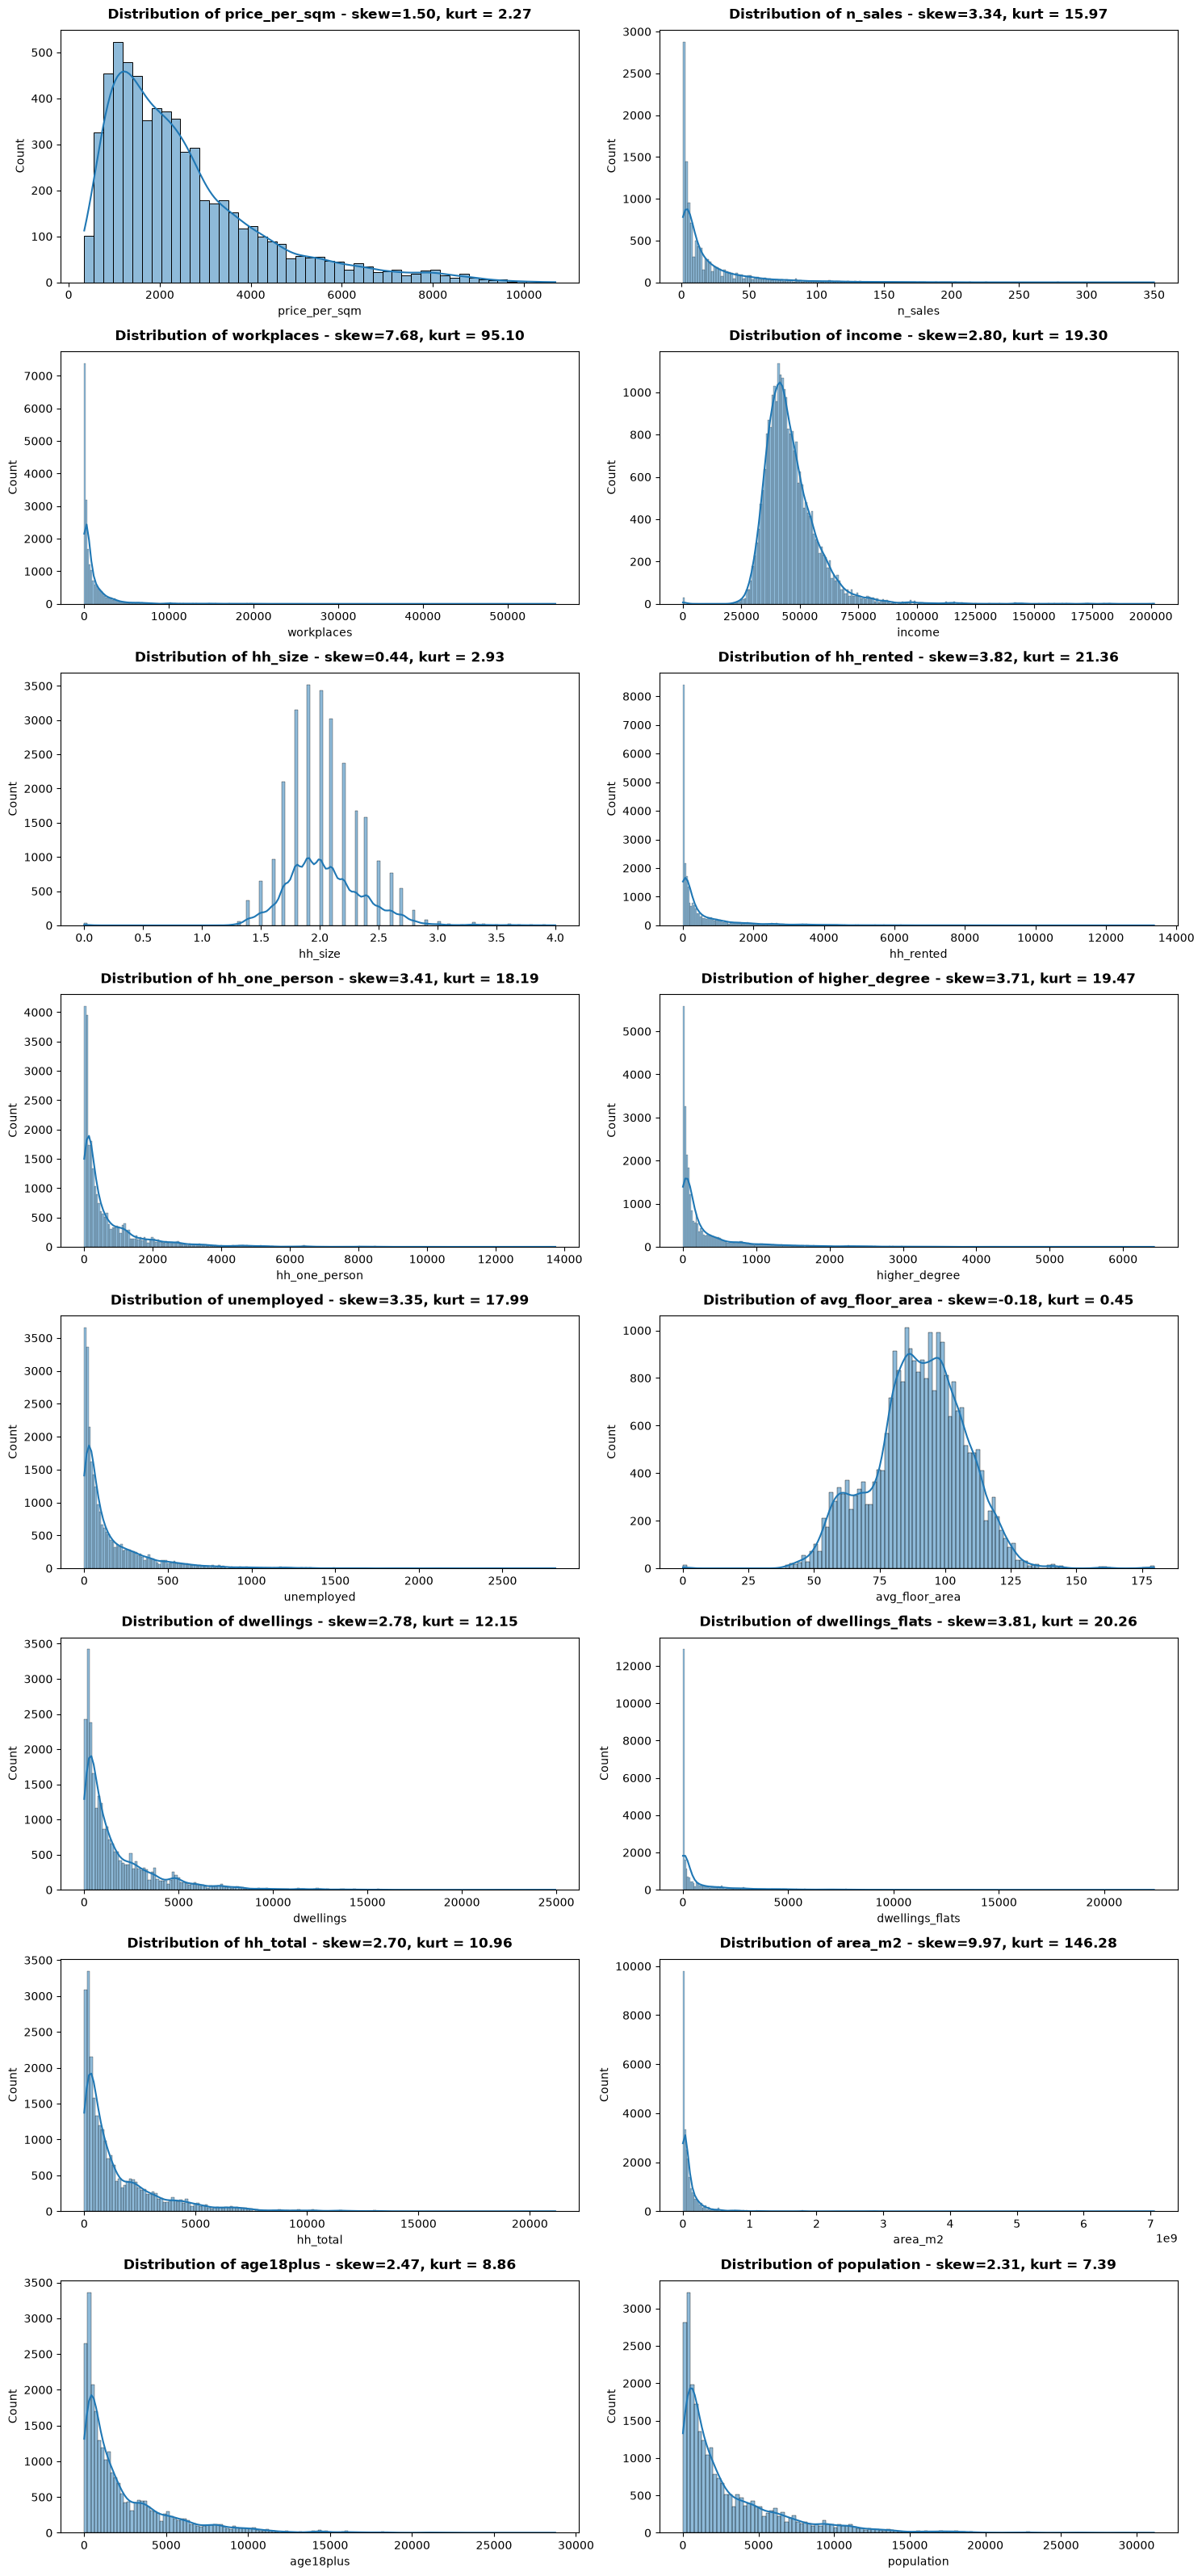

In [27]:
# Numeric columns
n_cols = 2
n_rows = 8

plt.figure(figsize=(15, 4 * n_rows))

for i, num_col in enumerate(num_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.histplot(data=df_merged, x=num_col, kde=True)
    plt.title(f'Distribution of {num_col} - skew={df_merged[num_col].skew():.2f}, kurt = {df_merged[num_col].kurt():.2f}' , pad=10, fontweight="bold")
    plt.xlabel(num_col)
    plt.ylabel('Count')

plt.tight_layout()
plt.show()

# Data Cleaning (before spliting)

## Handle zero values

In [28]:
zero_summary.sort_values('0_percentage', ascending=False)

,0_count,0_percentage
dwellings_flats,5532,21.392111
higher_degree,117,0.452436
hh_rented,93,0.359629
unemployed,60,0.232019
income,30,0.116009
hh_size,30,0.116009
hh_one_person,30,0.116009
hh_total,30,0.116009
age18plus,30,0.116009
population,30,0.116009


### Handle dwellings_flats 0 values

In [29]:
zero_dwellings_flats = df_merged[df_merged['dwellings_flats'] == 0][['postal_code', 'year', 'rooms', 'dwellings_flats', 'dwellings', 'price_per_sqm', 'n_sales']]
display(zero_dwellings_flats.shape)
zero_dwellings_flats.head()

(5532, 7)

,postal_code,year,rooms,dwellings_flats,dwellings,price_per_sqm,n_sales
85,01190,2020,1,0.0,453.0,NaN,NaN
120,01750,2020,1,0.0,348.0,NaN,NaN
124,01830,2020,1,0.0,950.0,NaN,NaN
128,01940,2020,1,0.0,328.0,NaN,NaN
144,02270,2020,1,0.0,904.0,NaN,NaN


In [30]:
zero_dwellings_flats[(zero_dwellings_flats['n_sales'].isna()) & (zero_dwellings_flats['price_per_sqm'].isna())]

,postal_code,year,rooms,dwellings_flats,dwellings,price_per_sqm,n_sales
85,01190,2020,1,0.0,453.0,NaN,NaN
120,01750,2020,1,0.0,348.0,NaN,NaN
124,01830,2020,1,0.0,950.0,NaN,NaN
128,01940,2020,1,0.0,328.0,NaN,NaN
144,02270,2020,1,0.0,904.0,NaN,NaN
...,...,...,...,...,...,...,...
25848,99645,2024,3,0.0,56.0,NaN,NaN
25849,99660,2024,3,0.0,32.0,NaN,NaN
25850,99690,2024,3,0.0,148.0,NaN,NaN
25851,99710,2024,3,0.0,147.0,NaN,NaN


These rows should be removed. But before that, it needs to calculate dwelling flats growth/change year by year.

#### Calculate dwelling_flats absolute growth/change

In [31]:
# Create one row per postal code and year
flat_stock = (
    df_merged[
        ["postal_code", "year", "dwellings_flats"]
    ]
    .drop_duplicates()
    .sort_values(["postal_code", "year"])
    .copy()
)

# Calculate annual change in the number of flats
flat_stock["flats_growth"] = (
    flat_stock.groupby("postal_code")["dwellings_flats"]
    .diff()
)

# Merge growth back to the long-format dataset
df_merged = df_merged.merge(
    flat_stock[
        ["postal_code", "year", "flats_growth"]
    ],
    on=["postal_code", "year"],
    how="left"
)

In [32]:
mask = (
    (df_merged["dwellings_flats"] == 0) &
    (df_merged["n_sales"].isna()) &
    (df_merged["price_per_sqm"].isna())
)

df_merged = df_merged[~mask].copy()

In [33]:
df_merged.head()

,postal_code,municipality,year,rooms,price_per_sqm,n_sales,population,age18plus,higher_degree,income,...,dwellings,dwellings_flats,avg_floor_area,unemployed,workplaces,municipality_code,centroid_x,centroid_y,area_m2,flats_growth
0,00100,Helsinki,2020,1,8419.0,110.0,18373.0,16236.0,6023.0,70284.0,...,12341.0,11721.0,65.8,1083.0,49712.0,091,385114.002032,6.672391e+06,2353278.0,NaN
1,00120,Helsinki,2020,1,8702.0,55.0,7216.0,6221.0,2275.0,74856.0,...,4777.0,4492.0,69.5,460.0,7131.0,091,385613.519532,6.671378e+06,414010.0,NaN
2,00130,Helsinki,2020,1,NaN,5.0,1721.0,1501.0,571.0,101682.0,...,1192.0,1000.0,78.5,81.0,11708.0,091,386227.614544,6.671492e+06,428960.0,NaN
3,00140,Helsinki,2020,1,8948.0,73.0,7995.0,6872.0,2595.0,92033.0,...,5391.0,5358.0,74.1,465.0,1919.0,091,386491.175934,6.670519e+06,931841.0,NaN
4,00150,Helsinki,2020,1,8739.0,134.0,9440.0,8322.0,2857.0,59378.0,...,6694.0,6616.0,55.9,682.0,4176.0,091,385117.961363,6.670308e+06,1367328.0,NaN


In [34]:
(df_merged['flats_growth'].isna().sum())

np.int64(4110)

In [35]:
new_num_cols = ['year', 'rooms', 'price_per_sqm',
       'n_sales', 'population', 'age18plus', 'higher_degree', 'income',
       'hh_size', 'hh_total', 'hh_rented', 'hh_one_person', 'dwellings',
       'dwellings_flats', 'avg_floor_area', 'unemployed', 'workplaces',
       'centroid_x', 'centroid_y', 'area_m2',
       'flats_growth']

zero_summary_new = pd.DataFrame({
  '0_count': (df_merged[new_num_cols] == 0).sum(),
  '0_percentage': (df_merged[new_num_cols]==0).mean()*100
})

zero_summary_new.sort_values('0_percentage', ascending=False)

,0_count,0_percentage
flats_growth,6230,30.635327
higher_degree,33,0.162274
unemployed,30,0.147522
hh_rented,21,0.103265
population,15,0.073761
income,15,0.073761
hh_size,15,0.073761
hh_total,15,0.073761
hh_one_person,15,0.073761
age18plus,15,0.073761


#### Handling zero values in `dwellings_flats`

The `dwellings_flats` variable represents the number of dwellings located in blocks of flats within each postal code area. Inspection of the data showed that many observations had `dwellings_flats = 0`, even though the total number of dwellings (`dwellings`) was greater than zero.

These zero values were not treated as missing values. Instead, they indicate that housing exists in the postal code area, but there were no dwellings classified as being in blocks of flats in that particular year. The housing stock in these areas may therefore consist mainly of other dwelling types, such as detached houses, terraced houses, semi-detached houses, or other forms of housing.

Further inspection showed that most observations with `dwellings_flats = 0` also had missing values for both `price_per_sqm` and `n_sales`. This is consistent with the scope of the apartment-price dataset: if there are no dwellings in blocks of flats in an area-year, there may also be no relevant apartment sales from which a price per square metre can be reported.

Before removing these observations, an annual flat-stock growth feature was investigated. The feature was calculated at the unique postal-code and year level as the difference between the current year's and previous year's number of dwellings in blocks of flats:

`flats_growth = dwellings_flats(t) - dwellings_flats(t-1)`

The calculation was performed before filtering the zero-flat observations so that changes from zero flats to a positive number of flats would still be captured. For example, an increase from 0 flats to 64 flats would produce a `flats_growth` value of +64.

After calculating this feature, however, its distribution showed limited usefulness for modelling. More than **6,000 observations had a `flats_growth` value of 0**, meaning that there was no recorded year-to-year change in the number of dwellings in blocks of flats for those observations. In addition, more than **4,000 observations had missing (`NaN`) growth values**. These missing values occur mainly for the first observed year of each postal code, because there is no previous year available in the dataset from which to calculate the change. Since the dataset is in long format with separate rows for different room categories, the same missing postal-code/year growth value is repeated across the room-category rows.

Because a large proportion of the `flats_growth` feature consists of either zero values or structurally missing first-year values, while the original `dwellings_flats` variable already provides direct information about the size of the local flat stock, `flats_growth` was not retained as a modelling feature. It was considered unlikely to add sufficient additional predictive information to justify the extra missing-value handling and complexity.

Finally, observations where all of the following conditions were true were removed from the modelling data:

- `dwellings_flats = 0`
- `n_sales` is missing
- `price_per_sqm` is missing

These observations contain no recorded block-of-flats stock and no available apartment sales or price information, and therefore fall outside the relevant scope of the apartment-price modelling task.
```


### Handle zero income/population/age18plus cols

In [36]:
df_merged = df_merged.drop(columns='flats_growth')
df_merged.head()

,postal_code,municipality,year,rooms,price_per_sqm,n_sales,population,age18plus,higher_degree,income,...,hh_one_person,dwellings,dwellings_flats,avg_floor_area,unemployed,workplaces,municipality_code,centroid_x,centroid_y,area_m2
0,00100,Helsinki,2020,1,8419.0,110.0,18373.0,16236.0,6023.0,70284.0,...,5379.0,12341.0,11721.0,65.8,1083.0,49712.0,091,385114.002032,6.672391e+06,2353278.0
1,00120,Helsinki,2020,1,8702.0,55.0,7216.0,6221.0,2275.0,74856.0,...,2042.0,4777.0,4492.0,69.5,460.0,7131.0,091,385613.519532,6.671378e+06,414010.0
2,00130,Helsinki,2020,1,NaN,5.0,1721.0,1501.0,571.0,101682.0,...,445.0,1192.0,1000.0,78.5,81.0,11708.0,091,386227.614544,6.671492e+06,428960.0
3,00140,Helsinki,2020,1,8948.0,73.0,7995.0,6872.0,2595.0,92033.0,...,2263.0,5391.0,5358.0,74.1,465.0,1919.0,091,386491.175934,6.670519e+06,931841.0
4,00150,Helsinki,2020,1,8739.0,134.0,9440.0,8322.0,2857.0,59378.0,...,3424.0,6694.0,6616.0,55.9,682.0,4176.0,091,385117.961363,6.670308e+06,1367328.0


In [37]:
zero_income_areas = df_merged[df_merged['income'] == 0]
zero_income_areas

,postal_code,municipality,year,rooms,price_per_sqm,n_sales,population,age18plus,higher_degree,income,...,hh_one_person,dwellings,dwellings_flats,avg_floor_area,unemployed,workplaces,municipality_code,centroid_x,centroid_y,area_m2
409,15980,Hollola,2020,1,NaN,NaN,0.0,0.0,0.0,0.0,...,0.0,NaN,NaN,NaN,0.0,26.0,098,421893.53889,6.765395e+06,3399089.0
2133,15980,Hollola,2020,2,NaN,NaN,0.0,0.0,0.0,0.0,...,0.0,NaN,NaN,NaN,0.0,26.0,098,421893.53889,6.765395e+06,3399089.0
3857,15980,Hollola,2020,3,NaN,NaN,0.0,0.0,0.0,0.0,...,0.0,NaN,NaN,NaN,0.0,26.0,098,421893.53889,6.765395e+06,3399089.0
5581,15980,Hollola,2021,1,NaN,NaN,0.0,0.0,0.0,0.0,...,0.0,NaN,NaN,NaN,0.0,26.0,098,421893.53889,6.765395e+06,3399089.0
7305,15980,Hollola,2021,2,NaN,NaN,0.0,0.0,0.0,0.0,...,0.0,NaN,NaN,NaN,0.0,26.0,098,421893.53889,6.765395e+06,3399089.0
9029,15980,Hollola,2021,3,NaN,NaN,0.0,0.0,0.0,0.0,...,0.0,NaN,NaN,NaN,0.0,26.0,098,421893.53889,6.765395e+06,3399089.0
10753,15980,Hollola,2022,1,NaN,NaN,0.0,0.0,0.0,0.0,...,0.0,NaN,NaN,NaN,0.0,27.0,098,421893.53889,6.765395e+06,3399089.0
12477,15980,Hollola,2022,2,NaN,NaN,0.0,0.0,0.0,0.0,...,0.0,NaN,NaN,NaN,0.0,27.0,098,421893.53889,6.765395e+06,3399089.0
14201,15980,Hollola,2022,3,NaN,NaN,0.0,0.0,0.0,0.0,...,0.0,NaN,NaN,NaN,0.0,27.0,098,421893.53889,6.765395e+06,3399089.0
15925,15980,Hollola,2023,1,NaN,NaN,0.0,0.0,0.0,0.0,...,0.0,NaN,NaN,NaN,0.0,30.0,098,421893.53889,6.765395e+06,3399089.0


In [38]:
zero_income_areas['postal_code'].unique()

<StringArray>
['15980']
Length: 1, dtype: str

In [39]:
df_merged.head()

,postal_code,municipality,year,rooms,price_per_sqm,n_sales,population,age18plus,higher_degree,income,...,hh_one_person,dwellings,dwellings_flats,avg_floor_area,unemployed,workplaces,municipality_code,centroid_x,centroid_y,area_m2
0,00100,Helsinki,2020,1,8419.0,110.0,18373.0,16236.0,6023.0,70284.0,...,5379.0,12341.0,11721.0,65.8,1083.0,49712.0,091,385114.002032,6.672391e+06,2353278.0
1,00120,Helsinki,2020,1,8702.0,55.0,7216.0,6221.0,2275.0,74856.0,...,2042.0,4777.0,4492.0,69.5,460.0,7131.0,091,385613.519532,6.671378e+06,414010.0
2,00130,Helsinki,2020,1,NaN,5.0,1721.0,1501.0,571.0,101682.0,...,445.0,1192.0,1000.0,78.5,81.0,11708.0,091,386227.614544,6.671492e+06,428960.0
3,00140,Helsinki,2020,1,8948.0,73.0,7995.0,6872.0,2595.0,92033.0,...,2263.0,5391.0,5358.0,74.1,465.0,1919.0,091,386491.175934,6.670519e+06,931841.0
4,00150,Helsinki,2020,1,8739.0,134.0,9440.0,8322.0,2857.0,59378.0,...,3424.0,6694.0,6616.0,55.9,682.0,4176.0,091,385117.961363,6.670308e+06,1367328.0


In [40]:
non_residential_postal_codes = ['15980', '93999']

df_merged = df_merged[~df_merged['postal_code'].isin(non_residential_postal_codes)].copy()

In [41]:
df_merged[(df_merged['income'] == 0) | (df_merged['population'] == 0) | (df_merged['age18plus'] == 0)]

,postal_code,municipality,year,rooms,price_per_sqm,n_sales,population,age18plus,higher_degree,income,...,hh_one_person,dwellings,dwellings_flats,avg_floor_area,unemployed,workplaces,municipality_code,centroid_x,centroid_y,area_m2


In [42]:
zero_summary_new.sort_values('0_percentage', ascending=False)

,0_count,0_percentage
flats_growth,6230,30.635327
higher_degree,33,0.162274
unemployed,30,0.147522
hh_rented,21,0.103265
population,15,0.073761
income,15,0.073761
hh_size,15,0.073761
hh_total,15,0.073761
hh_one_person,15,0.073761
age18plus,15,0.073761


#### Handling zero values in `income`, `population`, and `age18plus`

The variables `income`, `population`, and `age18plus` represent core socioeconomic and demographic characteristics of each postal code area.

During data inspection, a small number of observations contained zero values in these variables. These values were examined because a value of zero is not realistic for a populated residential postal code area, especially when several of these core variables are zero at the same time.

Further inspection showed that the zero values were concentrated in a very small number of postal code areas and were repeated across multiple years. These observations also had several other demographic variables recorded as zero or unavailable, indicating that they did not represent normal residential observations with complete socioeconomic information.

Because these zeros appear to reflect unavailable or unusable demographic information rather than genuine values, the affected postal code areas were excluded from the dataset instead of replacing the zeros with imputed values.

This approach avoids introducing artificial estimates for areas where several fundamental demographic characteristics are simultaneously unavailable. It also keeps the remaining dataset more consistent for modelling, since valid observations should contain meaningful values for income, population, and the adult population (`age18plus`).

After excluding these problematic postal code areas, no further zero-value replacement was required for `income`, `population`, or `age18plus`.
```


# Data Splitting

In [43]:
model_set = df_merged[df_merged['price_per_sqm'].notna()]
predict_set = df_merged[df_merged['price_per_sqm'].isna()]

display(model_set.shape)
display(predict_set.shape)

(6206, 23)

(14115, 23)

In [51]:
model_set.head()

,postal_code,municipality,year,rooms,price_per_sqm,n_sales,population,age18plus,higher_degree,income,...,hh_one_person,dwellings,dwellings_flats,avg_floor_area,unemployed,workplaces,municipality_code,centroid_x,centroid_y,area_m2
0,00100,Helsinki,2020,1,8419.0,110.0,18373.0,16236.0,6023.0,70284.0,...,5379.0,12341.0,11721.0,65.8,1083.0,49712.0,091,385114.002032,6.672391e+06,2353278.0
1,00120,Helsinki,2020,1,8702.0,55.0,7216.0,6221.0,2275.0,74856.0,...,2042.0,4777.0,4492.0,69.5,460.0,7131.0,091,385613.519532,6.671378e+06,414010.0
3,00140,Helsinki,2020,1,8948.0,73.0,7995.0,6872.0,2595.0,92033.0,...,2263.0,5391.0,5358.0,74.1,465.0,1919.0,091,386491.175934,6.670519e+06,931841.0
4,00150,Helsinki,2020,1,8739.0,134.0,9440.0,8322.0,2857.0,59378.0,...,3424.0,6694.0,6616.0,55.9,682.0,4176.0,091,385117.961363,6.670308e+06,1367328.0
5,00160,Helsinki,2020,1,8236.0,18.0,4995.0,4198.0,1503.0,80558.0,...,1058.0,2959.0,2872.0,77.3,269.0,3182.0,091,387315.063204,6.671716e+06,541136.0


In [52]:
gss = GroupShuffleSplit(
  n_splits=1,
  random_state=42,
  test_size=0.2
)

train_idx, test_idx = next(
  gss.split(
    model_set,
    groups=model_set['postal_code']
  )
)

train_data = model_set.iloc[train_idx].copy()
test_data = model_set.iloc[test_idx].copy()

In [53]:
display(train_data.shape)
display(test_data.shape)
train_data.head()

(4932, 23)

(1274, 23)

,postal_code,municipality,year,rooms,price_per_sqm,n_sales,population,age18plus,higher_degree,income,...,hh_one_person,dwellings,dwellings_flats,avg_floor_area,unemployed,workplaces,municipality_code,centroid_x,centroid_y,area_m2
0,00100,Helsinki,2020,1,8419.0,110.0,18373.0,16236.0,6023.0,70284.0,...,5379.0,12341.0,11721.0,65.8,1083.0,49712.0,091,385114.002032,6.672391e+06,2353278.0
1,00120,Helsinki,2020,1,8702.0,55.0,7216.0,6221.0,2275.0,74856.0,...,2042.0,4777.0,4492.0,69.5,460.0,7131.0,091,385613.519532,6.671378e+06,414010.0
3,00140,Helsinki,2020,1,8948.0,73.0,7995.0,6872.0,2595.0,92033.0,...,2263.0,5391.0,5358.0,74.1,465.0,1919.0,091,386491.175934,6.670519e+06,931841.0
4,00150,Helsinki,2020,1,8739.0,134.0,9440.0,8322.0,2857.0,59378.0,...,3424.0,6694.0,6616.0,55.9,682.0,4176.0,091,385117.961363,6.670308e+06,1367328.0
5,00160,Helsinki,2020,1,8236.0,18.0,4995.0,4198.0,1503.0,80558.0,...,1058.0,2959.0,2872.0,77.3,269.0,3182.0,091,387315.063204,6.671716e+06,541136.0


## Data Splitting Strategy

The dataset contains repeated observations for the same postal code across multiple years and room categories. Because of this structure, a standard random row-level train-test split would not be appropriate.

If rows from the same postal code appeared in both the training and test sets, the model could indirectly learn characteristics of that postal code during training and then be evaluated on another observation from the same area. This would make the test results overly optimistic and introduce spatial leakage.

To avoid this, the modelling data is split using `postal_code` as the grouping variable.

### 1. Separate known and missing target values

The target variable is `price_per_sqm`.

Rows where `price_per_sqm` is available are used as the modelling dataset. Rows where `price_per_sqm` is missing are kept separately as the prediction dataset.

The missing target values are not imputed, because these are the observations for which the final model is intended to estimate apartment prices.

### 2. Grouped train-test split

Only the rows with known apartment prices are used for model development and evaluation.

The modelling dataset is split into training and test sets using `GroupShuffleSplit`, with `postal_code` as the grouping variable.

This ensures that:

- all observations belonging to the same postal code stay in the same split,
- a postal code cannot appear in both the training and test sets,
- observations from different years and room categories of the same postal code remain together.

An 80/20 train-test split is used, with approximately 80% of the postal-code groups assigned to training and 20% assigned to testing.

### 3. Why this split is important

The main goal is to estimate apartment prices in areas where published price information is unavailable. Therefore, the evaluation should measure how well the model performs on postal codes that it has not seen during training.

Using a grouped split provides a more realistic estimate of this generalization ability than a random row-level split.

After the best-performing model has been selected and evaluated, it can later be retrained using all available rows with published `price_per_sqm` values and then used to estimate the missing prices in the prediction dataset.
```


# EDA on Train data

### Basic understanding

In [65]:
display(train_data.shape)
train_data.head()

(4932, 23)

,postal_code,municipality,year,rooms,price_per_sqm,n_sales,population,age18plus,higher_degree,income,...,hh_one_person,dwellings,dwellings_flats,avg_floor_area,unemployed,workplaces,municipality_code,centroid_x,centroid_y,area_m2
0,00100,Helsinki,2020,1,8419.0,110.0,18373.0,16236.0,6023.0,70284.0,...,5379.0,12341.0,11721.0,65.8,1083.0,49712.0,091,385114.002032,6.672391e+06,2353278.0
1,00120,Helsinki,2020,1,8702.0,55.0,7216.0,6221.0,2275.0,74856.0,...,2042.0,4777.0,4492.0,69.5,460.0,7131.0,091,385613.519532,6.671378e+06,414010.0
3,00140,Helsinki,2020,1,8948.0,73.0,7995.0,6872.0,2595.0,92033.0,...,2263.0,5391.0,5358.0,74.1,465.0,1919.0,091,386491.175934,6.670519e+06,931841.0
4,00150,Helsinki,2020,1,8739.0,134.0,9440.0,8322.0,2857.0,59378.0,...,3424.0,6694.0,6616.0,55.9,682.0,4176.0,091,385117.961363,6.670308e+06,1367328.0
5,00160,Helsinki,2020,1,8236.0,18.0,4995.0,4198.0,1503.0,80558.0,...,1058.0,2959.0,2872.0,77.3,269.0,3182.0,091,387315.063204,6.671716e+06,541136.0


In [66]:
display(train_data.info())
train_data.describe()

<class 'pandas.DataFrame'>
Index: 4932 entries, 0 to 25804
Data columns (total 23 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   postal_code        4932 non-null   str    
 1   municipality       4932 non-null   str    
 2   year               4932 non-null   int64  
 3   rooms              4932 non-null   int64  
 4   price_per_sqm      4932 non-null   float64
 5   n_sales            4932 non-null   float64
 6   population         4932 non-null   float64
 7   age18plus          4932 non-null   float64
 8   higher_degree      4932 non-null   float64
 9   income             4932 non-null   float64
 10  hh_size            4932 non-null   float64
 11  hh_total           4932 non-null   float64
 12  hh_rented          4932 non-null   float64
 13  hh_one_person      4932 non-null   float64
 14  dwellings          4932 non-null   float64
 15  dwellings_flats    4932 non-null   float64
 16  avg_floor_area     4932 non-null   floa

None

,year,rooms,price_per_sqm,n_sales,population,age18plus,higher_degree,income,hh_size,hh_total,hh_rented,hh_one_person,dwellings,dwellings_flats,avg_floor_area,unemployed,workplaces,centroid_x,centroid_y,area_m2
count,4932.000000,4932.000000,4932.000000,4932.000000,4932.000000,4932.000000,4932.000000,4932.000000,4932.000000,4932.000000,4932.000000,4932.000000,4932.000000,4932.000000,4932.000000,4932.000000,4022.000000,4932.000000,4.932000e+03,4.932000e+03
mean,2021.928427,2.067315,2493.124696,34.306367,7395.359084,6157.423560,932.346918,42991.806772,1.830819,4044.651663,1898.419505,2091.730535,4499.330089,3098.700324,71.344931,428.935726,3276.906266,391987.931526,6.819835e+06,5.980036e+07
std,1.393537,0.777087,1719.584116,35.655794,4278.418953,3627.099294,889.468536,11682.307489,0.239759,2461.163989,1548.901253,1478.211122,2757.253352,2665.551866,12.651858,297.558119,4714.406599,94718.316097,1.681979e+05,2.398859e+08
min,2020.000000,1.000000,341.000000,6.000000,76.000000,69.000000,5.000000,21612.000000,1.300000,40.000000,3.000000,15.000000,73.000000,0.000000,39.400000,3.000000,29.000000,201936.155414,6.641830e+06,2.306480e+05
25%,2021.000000,1.000000,1254.750000,12.000000,4244.250000,3522.750000,340.000000,35765.000000,1.700000,2333.000000,856.000000,1127.000000,2622.000000,1277.000000,61.000000,229.000000,1064.250000,329978.402421,6.683865e+06,2.656153e+06
50%,2022.000000,2.000000,2019.000000,22.000000,6434.000000,5360.000000,660.000000,40505.500000,1.800000,3474.500000,1431.000000,1723.000000,3840.500000,2226.000000,70.500000,365.000000,2008.000000,385742.857444,6.762589e+06,6.101556e+06
75%,2023.000000,3.000000,3155.000000,43.000000,9644.000000,7972.000000,1252.500000,47587.250000,2.000000,5053.000000,2530.000000,2668.000000,5574.000000,4215.000000,81.300000,544.000000,3624.000000,431922.667618,6.901651e+06,2.705608e+07
max,2024.000000,3.000000,10318.000000,350.000000,31156.000000,28743.000000,6422.000000,156196.000000,2.700000,21145.000000,13367.000000,13739.000000,24952.000000,22365.000000,125.300000,2816.000000,55646.000000,667568.068276,7.525393e+06,4.034476e+09


### Check missing values

In [58]:
train_data.isnull().sum()

postal_code            0
municipality           0
year                   0
rooms                  0
price_per_sqm          0
n_sales                0
population             0
age18plus              0
higher_degree          0
income                 0
hh_size                0
hh_total               0
hh_rented              0
hh_one_person          0
dwellings              0
dwellings_flats        0
avg_floor_area         0
unemployed             0
workplaces           910
municipality_code      0
centroid_x             0
centroid_y             0
area_m2                0
dtype: int64

In [60]:
train_data[train_data['workplaces'].isna()]['year'].unique()

array([2024])

### Check distribution

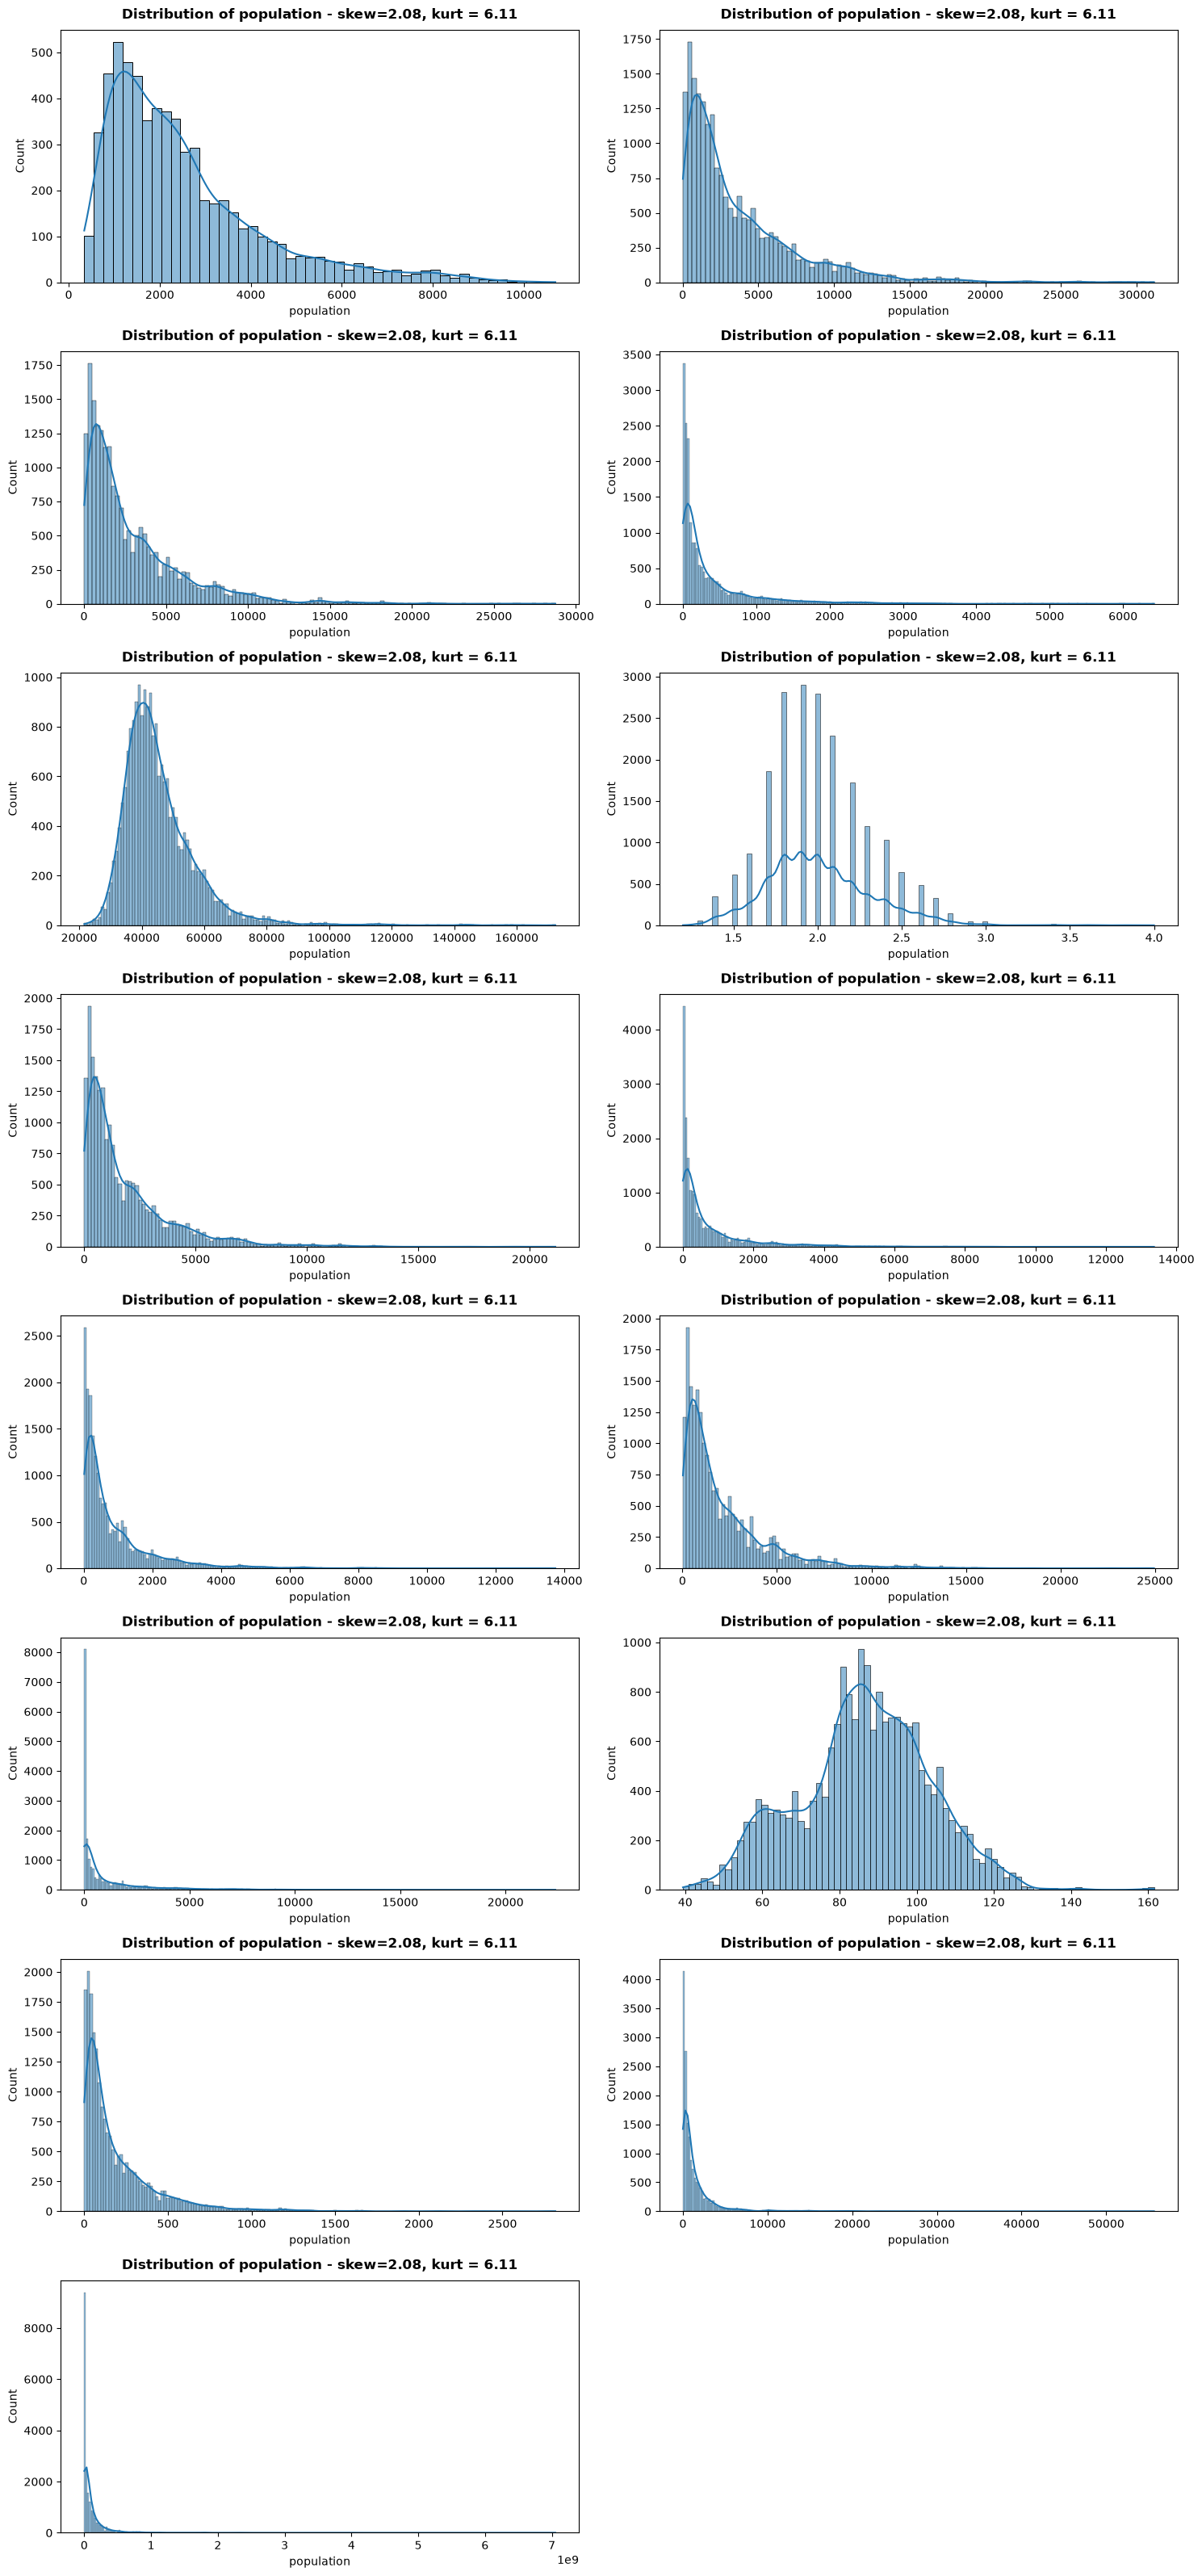

In [64]:
distribution_cols = [
    "price_per_sqm",
    "population",
    "age18plus",
    "higher_degree",
    "income",
    "hh_size",
    "hh_total",
    "hh_rented",
    "hh_one_person",
    "dwellings",
    "dwellings_flats",
    "avg_floor_area",
    "unemployed",
    "workplaces",
    "area_m2"
]

# Numeric columns
n_cols = 2
n_rows = 8

plt.figure(figsize=(15, 4 * n_rows))

for i, d_col in enumerate(distribution_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.histplot(data=df_merged, x=d_col, kde=True)
    plt.title(f'Distribution of {num_col} - skew={df_merged[num_col].skew():.2f}, kurt = {df_merged[num_col].kurt():.2f}' , pad=10, fontweight="bold")
    plt.xlabel(num_col)
    plt.ylabel('Count')

plt.tight_layout()
plt.show()